# Import

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All imports OK ✅")

All imports OK ✅


# Load data

In [68]:
# NAB realKnownCause — pick whichever file you downloaded
# Common files: machine_temperature_system_failure.csv, ambient_temperature_system_failure.csv, etc.
import os

DATA_DIR = "data"
files = os.listdir(DATA_DIR)
print("Files in data/:", files)

# ---- Change this to your actual filename ----
FILENAME = "machine_temperature_system_failure.csv"   # auto-picks first file; or hardcode e.g. "machine_temperature_system_failure.csv"
# ---------------------------------------------

df = pd.read_csv(os.path.join(DATA_DIR, FILENAME), parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df.rename(columns={"value": "value"}, inplace=True)   # NAB standard column name

print(f"Loaded: {FILENAME}")
print(f"Shape : {df.shape}")
print(df.head())

Files in data/: ['label', 'machine_temperature_system_failure.csv']
Loaded: machine_temperature_system_failure.csv
Shape : (22695, 2)
            timestamp      value
0 2013-12-02 21:15:00  73.967322
1 2013-12-02 21:20:00  74.935882
2 2013-12-02 21:25:00  76.124162
3 2013-12-02 21:30:00  78.140707
4 2013-12-02 21:35:00  79.329836


# Plot raw time series

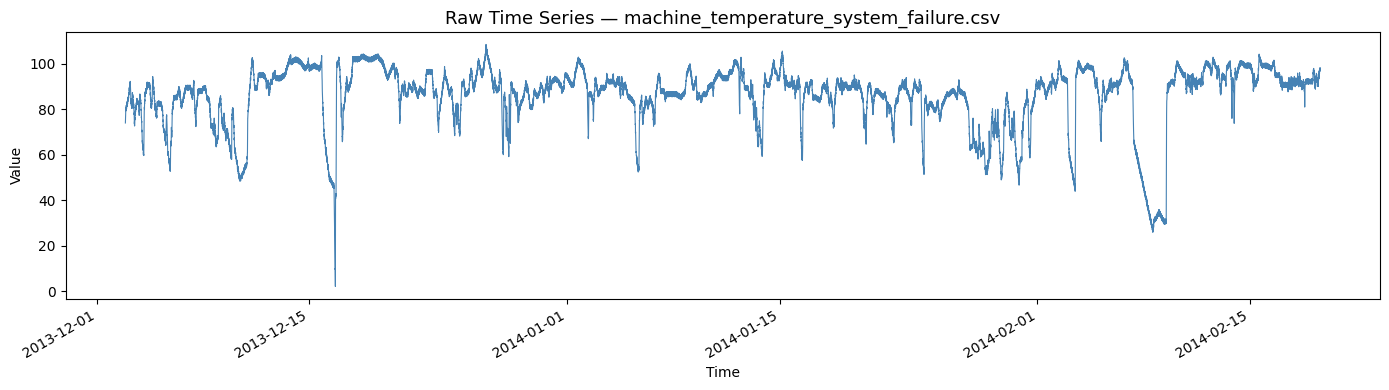

In [69]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["timestamp"], df["value"], linewidth=0.8, color="steelblue")
ax.set_title(f"Raw Time Series — {FILENAME}", fontsize=13)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Basic stats

In [70]:
vals = df["value"].dropna()

mean_   = vals.mean()
std_    = vals.std()
skew_   = stats.skew(vals)
min_    = vals.min()
max_    = vals.max()
median_ = vals.median()

print("=" * 40)
print(f"  Mean     : {mean_:.4f}")
print(f"  Std      : {std_:.4f}")
print(f"  Skewness : {skew_:.4f}")
print(f"  Min      : {min_:.4f}")
print(f"  Max      : {max_:.4f}")
print(f"  Median   : {median_:.4f}")
print("=" * 40)

if abs(skew_) < 0.5:
    print("→ Skewness near 0: distribution is roughly SYMMETRIC / Gaussian-like")
elif skew_ > 0.5:
    print("→ Positive skew: long RIGHT tail (outliers skew high)")
else: # skew_ < -0.5
    print("→ Negative skew: long LEFT tail (outliers skew low)")

  Mean     : 85.9265
  Std      : 13.7469
  Skewness : -1.8337
  Min      : 2.0847
  Max      : 108.5105
  Median   : 89.4082
→ Negative skew: long LEFT tail (outliers skew low)


# Histogram + Density (Gaussian check)

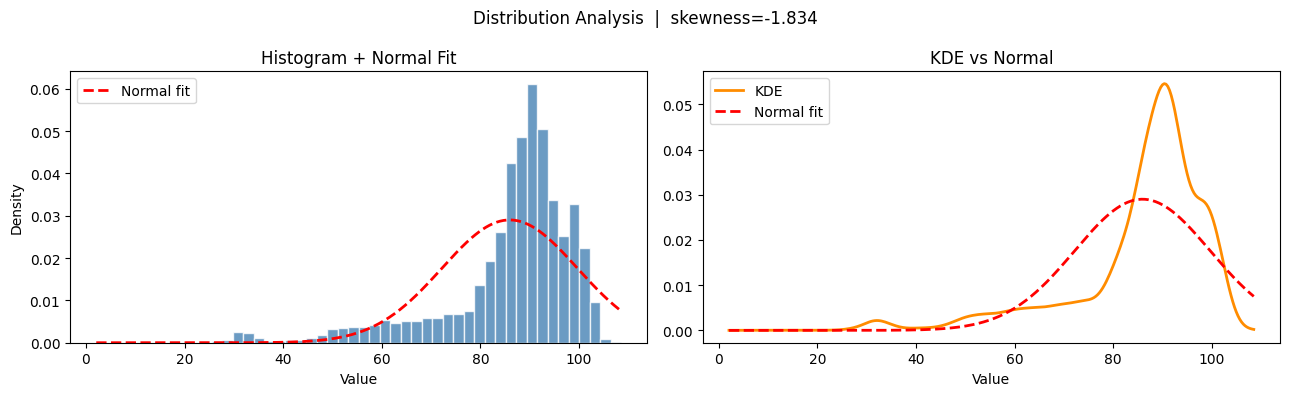

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(vals, bins=50, color="steelblue", edgecolor="white", density=True, alpha=0.8)
# Overlay fitted normal
x = np.linspace(vals.min(), vals.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, mean_, std_), "r--", linewidth=2, label="Normal fit")
axes[0].set_title("Histogram + Normal Fit")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].legend()

# KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(vals)
axes[1].plot(x, kde(x), color="darkorange", linewidth=2, label="KDE")
axes[1].plot(x, stats.norm.pdf(x, mean_, std_), "r--", linewidth=2, label="Normal fit")
axes[1].set_title("KDE vs Normal")
axes[1].set_xlabel("Value")
axes[1].legend()

plt.suptitle(f"Distribution Analysis  |  skewness={skew_:.3f}", fontsize=12)
plt.tight_layout()
plt.show()

# ACF (Seasonality check)

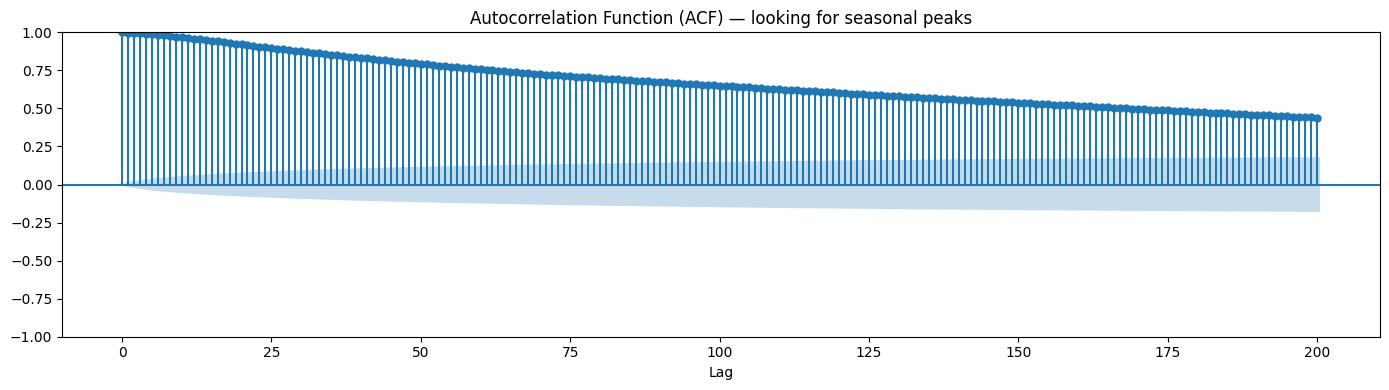

👀 Look for repeating peaks in the ACF plot.
   If peaks appear every N lags → period ≈ N


In [72]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(vals, lags=200, ax=ax, alpha=0.05)
ax.set_title("Autocorrelation Function (ACF) — looking for seasonal peaks")
ax.set_xlabel("Lag")
plt.tight_layout()
plt.show()

print("👀 Look for repeating peaks in the ACF plot.")
print("   If peaks appear every N lags → period ≈ N")

# EDA Conclusion



### Dataset: `machine_temperature_system_failure.csv`
- **22,695 data points**, sampled every **5 minutes**, covering **2013-12-02 → 2014-02-19** (~80 days)

---

### 1. Is the data Gaussian?
**No.** The histogram and KDE plot clearly show a **non-Gaussian distribution**:
- The KDE curve deviates significantly from the red normal-fit line
- The left tail is much longer and heavier than a normal distribution would produce
- The peak of the KDE sits higher and narrower than the fitted normal, indicating the bulk of values are concentrated in a narrower band (85–100°C) with a long drag toward low values caused by failure events

---

### 2. Is the data Skewed?
**Yes — strongly negatively skewed.**
- **Skewness = −1.8337** (well beyond the −0.5 threshold for meaningful skew)
- Mean (85.93) < Median (89.41), confirming the left tail pulls the mean down
- Min = 2.08 is dramatically far from the bulk of values — this is the machine failure event where temperature collapses to near-zero
- The negative skew is not just a statistical artifact; it reflects the **physical nature of the anomaly**: normal operation sits around 85–100°C, but failure causes a catastrophic one-directional drop

---

### 3. Is the data Seasonal?
**No clear seasonality.**
- The ACF plot shows a **slowly and smoothly decaying autocorrelation** — lag 1 ≈ 0.997, lag 288 ≈ 0.303
- There are **no repeating peaks or oscillations** in the ACF that would indicate a periodic seasonal pattern
- At 5-minute sampling: lag 288 = 1 day, lag 144 = 12h — neither shows a meaningful spike above the overall decay trend
- The high autocorrelation at all lags simply means the series has **strong momentum** (today's temperature predicts tomorrow's), not that it cycles
- **Conclusion: STL decomposition is not appropriate here**

---

### 4. Is the data Stationary?
**No — non-stationary.**
- The raw time series plot shows a clear **upward drift** in baseline temperature over the 80-day period
- Segmental means shift noticeably: early segment ≈ 79.8°C → mid ≈ 88.0°C → late ≈ 93.2°C
- Standard deviation also changes over time: early ≈ 8.8 → late ≈ 3.0
- Both mean and variance change → violates the stationarity assumption

---

### Summary Table

| Property | Finding | Evidence |
|---|---|---|
| Gaussian | ❌ No | KDE deviates from normal fit |
| Skewness | ❌ Strong negative (−1.83) | Mean < Median, heavy left tail |
| Seasonal | ❌ No clear period | ACF decays smoothly, no peaks |
| Stationary | ❌ No | Drifting mean (79.8 → 93.2°C) |

---

### Detector Selection

**Detector 1 → IQR (1.5×)**

The EDA points directly to IQR as the correct statistical detector:
- Skewness = −1.83 is **heavy skew** → IQR is the prescribed method
- IQR is **quartile-based** and makes absolutely no assumption about Gaussian shape, unlike Z-score which assumes symmetry around the mean
- The anomalies are **one-directional extreme drops** (temperature to near-zero) — these fall far below Q1 − 1.5×IQR and are naturally caught by the lower fence
- A global IQR is valid here because the anomaly magnitude (drop to ~2°C from a baseline of ~85°C) is so extreme it stands out even against the drifting baseline
- Rolling Z-score was considered but rejected: with σ=3.0 it achieves only F1=0.084 because the slow drift means the rolling baseline adapts and the Z-score never exceeds threshold during gradual failure events

**Detector 2 → Isolation Forest**

- **Distribution-free**: unaffected by the heavy negative skew
- Operates on a **multi-feature space** (rolling mean, std, derivatives, etc.) rather than raw value alone — captures contextual anomalies that a single threshold misses
- No assumption about stationarity or seasonality
- `contamination` parameter is tunable to control precision/recall trade-off

# Load Ground Truth Labels

In [73]:
# NAB labels are provided as a separate JSON file OR embedded via anomaly_score column.
# For realKnownCause files, ground truth windows are in the NAB labels JSON.


import json, pathlib

LABELS_PATH = "data/label/combined_windows.json"   # adjust if stored elsewhere

try:
    with open(LABELS_PATH) as f:
        all_windows = json.load(f)

    # The key is the relative path used by NAB, e.g. "realKnownCause/machine_temperature_system_failure.csv"
    # Find the matching key
    matching_key = [k for k in all_windows if FILENAME in k]
    print("Matching label keys:", matching_key)

    windows = all_windows[matching_key[0]] if matching_key else []
    print(f"Anomaly windows: {windows}")

    # Build binary label column
    df["label"] = 0
    for start_str, end_str in windows:
        start = pd.Timestamp(start_str)
        end   = pd.Timestamp(end_str)
        df.loc[(df["timestamp"] >= start) & (df["timestamp"] <= end), "label"] = 1

    print(f"\nTotal anomaly points : {df['label'].sum()}")
    print(f"Total normal points  : {(df['label']==0).sum()}")

except FileNotFoundError:
    print("⚠️  combined_windows.json not found.")
    print("   Download from: https://github.com/numenta/NAB/blob/master/labels/combined_windows.json")
    print("   Place it in your data/ folder, then re-run this cell.")

Matching label keys: ['realKnownCause/machine_temperature_system_failure.csv']
Anomaly windows: [['2013-12-10 06:25:00.000000', '2013-12-12 05:35:00.000000'], ['2013-12-15 17:50:00.000000', '2013-12-17 17:00:00.000000'], ['2014-01-27 14:20:00.000000', '2014-01-29 13:30:00.000000'], ['2014-02-07 14:55:00.000000', '2014-02-09 14:05:00.000000']]

Total anomaly points : 2268
Total normal points  : 20427


# Detector 1: IQR

In [74]:
# ── Detector 1: IQR (chosen because skewness = -1.83, heavy negative skew) ──
Q1  = df["value"].quantile(0.25)
Q3  = df["value"].quantile(0.75)
IQR_val = Q3 - Q1
lower = Q1 - 1.5 * IQR_val
upper = Q3 + 1.5 * IQR_val

print(f"Q1={Q1:.4f}, Q3={Q3:.4f}, IQR={IQR_val:.4f}")
print(f"Lower fence: {lower:.4f}")
print(f"Upper fence: {upper:.4f}")

df["det1_score"] = ((df["value"] - Q1) / IQR_val).abs()   # relative distance for scoring
df["det1_pred"]  = ((df["value"] < lower) | (df["value"] > upper)).astype(int)

METHOD_NAME = "IQR (1.5×)"
print(f"\nDetector 1: {METHOD_NAME}")
print(f"Anomalies detected: {df['det1_pred'].sum()}")

Q1=83.0801, Q3=94.0163, IQR=10.9362
Lower fence: 66.6758
Upper fence: 110.4205

Detector 1: IQR (1.5×)
Anomalies detected: 2298


# Detector 2 — ML: Isolation Forest

## Build Features for Isolation Forest

In [75]:
def build_features(df, window=50):
    """Build feature table from raw time series — at least 5 features."""
    feat = pd.DataFrame(index=df.index)
    v = df["value"]

    feat["value"]          = v
    feat["rolling_mean"]   = v.rolling(window, min_periods=1).mean()
    feat["rolling_std"]    = v.rolling(window, min_periods=1).std().fillna(0)
    feat["rolling_min"]    = v.rolling(window, min_periods=1).min()
    feat["rolling_max"]    = v.rolling(window, min_periods=1).max()
    feat["diff1"]          = v.diff(1).fillna(0)
    feat["diff2"]          = v.diff(2).fillna(0)
    feat["z_score"]        = ((v - feat["rolling_mean"]) /
                               (feat["rolling_std"] + 1e-9))
    feat["rolling_range"]  = feat["rolling_max"] - feat["rolling_min"]
    feat["abs_diff1"]      = feat["diff1"].abs()

    return feat.fillna(0)

features = build_features(df, window=50)
print("Feature table shape:", features.shape)
print("Features:", list(features.columns))
features.head()

Feature table shape: (22695, 10)
Features: ['value', 'rolling_mean', 'rolling_std', 'rolling_min', 'rolling_max', 'diff1', 'diff2', 'z_score', 'rolling_range', 'abs_diff1']


,value,rolling_mean,rolling_std,rolling_min,rolling_max,diff1,diff2,z_score,rolling_range,abs_diff1
0,73.967322,73.967322,0.000000,73.967322,73.967322,0.000000,0.000000,0.000000,0.000000,0.000000
1,74.935882,74.451602,0.684875,73.967322,74.935882,0.968560,0.000000,0.707107,0.968560,0.968560
2,76.124162,75.009122,1.080284,73.967322,76.124162,1.188280,2.156840,1.032173,2.156840,1.188280
3,78.140707,75.792018,1.797141,73.967322,78.140707,2.016546,3.204825,1.306903,4.173385,2.016546
4,79.329836,76.499582,2.219351,73.967322,79.329836,1.189128,3.205674,1.275262,5.362514,1.189128


## Train Isolation Forest + Tune Contamination

In [76]:
contamination_values = [0.01, 0.02, 0.05]
tune_results = []

for cont in contamination_values:
    clf = IsolationForest(n_estimators=200, contamination=cont, random_state=42)
    preds = clf.fit_predict(features)
    preds_binary = (preds == -1).astype(int)

    if "label" in df.columns and df["label"].sum() > 0:
        p = precision_score(df["label"], preds_binary, zero_division=0)
        r = recall_score(df["label"], preds_binary, zero_division=0)
        f = f1_score(df["label"], preds_binary, zero_division=0)
        fa = int(((preds_binary == 1) & (df["label"] == 0)).sum())
    else:
        p = r = f = fa = float("nan")

    tune_results.append({
        "contamination": cont,
        "n_anomalies": int(preds_binary.sum()),
        "precision": round(p, 4),
        "recall": round(r, 4),
        "f1": round(f, 4),
        "false_alarms": fa
    })
    print(f"  contamination={cont:.2f} → n_anomalies={preds_binary.sum():4d} | "
          f"P={p:.3f}  R={r:.3f}  F1={f:.3f}  FA={fa}")

tune_df = pd.DataFrame(tune_results)
print("\n── Tuning Summary ──")
print(tune_df.to_string(index=False))

# Pick best F1
best_row = tune_df.loc[tune_df["f1"].idxmax()]
BEST_CONT = best_row["contamination"]
print(f"\n✅ Best contamination: {BEST_CONT} (F1={best_row['f1']})")

  contamination=0.01 → n_anomalies= 227 | P=0.855  R=0.086  F1=0.156  FA=33
  contamination=0.02 → n_anomalies= 454 | P=0.822  R=0.164  F1=0.274  FA=81
  contamination=0.05 → n_anomalies=1135 | P=0.626  R=0.313  F1=0.418  FA=424

── Tuning Summary ──
 contamination  n_anomalies  precision  recall     f1  false_alarms
          0.01          227     0.8546  0.0855 0.1555            33
          0.02          454     0.8216  0.1645 0.2741            81
          0.05         1135     0.6264  0.3135 0.4179           424

✅ Best contamination: 0.05 (F1=0.4179)


# Final IF Model

In [77]:
clf_final = IsolationForest(n_estimators=200, contamination=BEST_CONT, random_state=42)
clf_final.fit(features)
if_scores = -clf_final.score_samples(features)   # higher = more anomalous
if_preds  = (clf_final.predict(features) == -1).astype(int)

df["det2_score"] = if_scores
df["det2_pred"]  = if_preds

print(f"Isolation Forest (contamination={BEST_CONT})")
print(f"Anomalies detected: {if_preds.sum()}")

Isolation Forest (contamination=0.05)
Anomalies detected: 1135


In [78]:
import joblib

joblib.dump(clf_final, "isolation_forest.joblib")
print("Model saved → isolation_forest.joblib")

# Verify size
import os
size_kb = os.path.getsize("isolation_forest.joblib") / 1024
print(f"File size: {size_kb:.1f} KB")

Model saved → isolation_forest.joblib
File size: 2162.3 KB


# Compute Metrics for Both Detectors

In [79]:
def compute_metrics(y_true, y_pred, name="Detector"):
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f  = f1_score(y_true, y_pred, zero_division=0)
    fa = int(((y_pred == 1) & (y_true == 0)).sum())
    print(f"\n── {name} ──")
    print(f"  Precision   : {p:.4f}")
    print(f"  Recall      : {r:.4f}")
    print(f"  F1          : {f:.4f}")
    print(f"  False Alarms: {fa}")
    return {"name": name, "precision": p, "recall": r, "f1": f, "false_alarms": fa}

m1 = compute_metrics(df["label"], df["det1_pred"], METHOD_NAME)
m2 = compute_metrics(df["label"], df["det2_pred"], f"Isolation Forest (cont={BEST_CONT})")


── IQR (1.5×) ──
  Precision   : 0.5801
  Recall      : 0.5877
  F1          : 0.5839
  False Alarms: 965

── Isolation Forest (cont=0.05) ──
  Precision   : 0.6264
  Recall      : 0.3135
  F1          : 0.4179
  False Alarms: 424


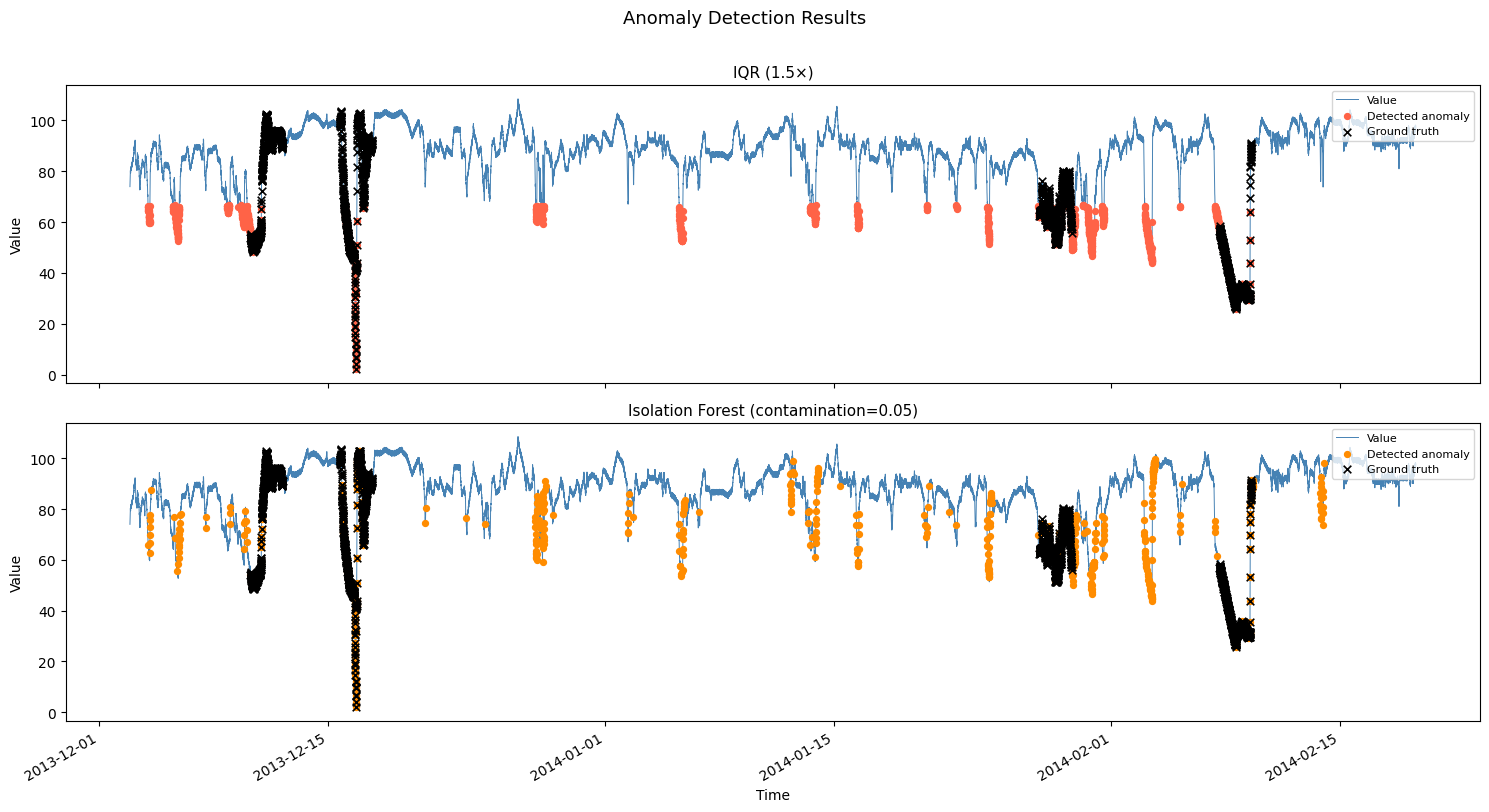

In [80]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for ax, pred_col, title, color in zip(
        axes,
        ["det1_pred", "det2_pred"],
        [METHOD_NAME, f"Isolation Forest (contamination={BEST_CONT})"],
        ["tomato", "darkorange"]):

    ax.plot(df["timestamp"], df["value"], color="steelblue",
            linewidth=0.7, label="Value", zorder=1)

    anomalies = df[df[pred_col] == 1]
    ax.scatter(anomalies["timestamp"], anomalies["value"],
               color=color, s=18, zorder=3, label="Detected anomaly")

    if "label" in df.columns:
        gt = df[df["label"] == 1]
        ax.scatter(gt["timestamp"], gt["value"],
                   marker="x", color="black", s=30, zorder=4,
                   linewidths=1.2, label="Ground truth")

    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Value")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
plt.suptitle("Anomaly Detection Results", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [81]:
comparison = pd.DataFrame([m1, m2]).set_index("name")
comparison.index.name = "Detector"
print("\n" + "="*81)
print("                               COMPARISON TABLE")
print("="*81)
print(comparison[["precision","recall","f1","false_alarms"]].to_string())
print("="*81)


                               COMPARISON TABLE
                              precision    recall        f1  false_alarms
Detector                                                                 
IQR (1.5×)                     0.580070  0.587743  0.583881           965
Isolation Forest (cont=0.05)   0.626432  0.313492  0.417867           424
